In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
import cmocean as cmo
import xesmf as xe
import matplotlib

In [2]:
import psutil
from dask.distributed import Client, LocalCluster

# Detect system resources
n_physical_cores = psutil.cpu_count(logical=False)
n_logical_cores = psutil.cpu_count(logical=True)
total_mem = psutil.virtual_memory().total  # in bytes

# Decide how much memory to give to Dask (80% of total)
mem_per_worker = int((total_mem * 0.8) / n_physical_cores)

print(f"Physical cores: {n_physical_cores}")
print(f"Logical cores: {n_logical_cores}")
print(f"Total memory: {round(total_mem/1024**3, 2)} GB")
print(f"Memory per worker: {round(mem_per_worker/1024**3, 2)} GB")

# Set up the cluster
cluster = LocalCluster(
    n_workers=n_physical_cores,
    threads_per_worker=1,  # keep workers isolated
    memory_limit=mem_per_worker,
)

client = Client(cluster)
print(client)

Physical cores: 8
Logical cores: 8
Total memory: 16.0 GB
Memory per worker: 1.6 GB
<Client: 'tcp://127.0.0.1:52412' processes=8 threads=8, memory=12.80 GiB>


In [ ]:
client.close()
cluster.close()

## Creating SOhi static file and regridded ID shelf for BGOSE based on SOhi shelves

In [ ]:
ds = xr.open_dataset("for_Jeremy/2007_03-v2.nc")

ds["lon"] = ds["lon"] % 360
ds["lon"] = ds.lon.assign_attrs({"units": "Degrees_east", "long_name": "Longitude"})

# ds = ds.sortby('lon')
ds

In [ ]:
ID = np.load("data/masks/iceshelvesID.npy")
area = np.load("data/masks/area.npy")

In [ ]:
ds["ID"] = (("lat", "lon"), ID)
ds["area"] = (("lat", "lon"), area)

ds_out = ds.drop_dims("date")

In [ ]:
ds_out.to_netcdf("data/SOhi.static.nc")

In [ ]:
(ds_out.area * ds_out.ID).plot()

### Creating IDs for BGOSE

In [3]:
ds_BGOSE = xr.open_dataset("BGOSE6/SHIfwFlx_bgoseI000_SO_monthly.nc")
ds_SOhi = xr.open_dataset("data/SOhi.static.nc")

In [4]:
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ds_BGOSE.YC.data),
        "lon": (["lon"], ds_BGOSE.XC.data),
    }
)
ds_out

<xarray.Dataset> Size: 11kB
Dimensions:  (lat: 614, lon: 2160)
Coordinates:
  * lat      (lat) float32 2kB -82.97 -82.91 -82.84 ... -30.39 -30.25 -30.11
  * lon      (lon) float32 9kB 0.08333 0.25 0.4167 0.5833 ... 359.6 359.8 359.9
Data variables:
    *empty*

In [5]:
regridder = xe.Regridder(ds_SOhi, ds_out, "nearest_s2d", periodic=True)
regridder  # print basic regridder information.

xESMF Regridder 
Regridding algorithm:       nearest_s2d 
Weight filename:            nearest_s2d_2344x8640_614x2160_peri.nc 
Reuse pre-computed weights? False 
Input grid shape:           (2344, 8640) 
Output grid shape:          (614, 2160) 
Periodic in longitude?      True

In [6]:
ds_regridded = regridder(ds_SOhi, keep_attrs=True)
ds_regridded

<xarray.Dataset> Size: 16MB
Dimensions:  (lat: 614, lon: 2160, depth: 225)
Coordinates:
  * depth    (depth) float32 900B -0.7 -2.117 -3.57 ... -5.879e+03 -5.929e+03
  * lat      (lat) float32 2kB -82.97 -82.91 -82.84 ... -30.39 -30.25 -30.11
  * lon      (lon) float32 9kB 0.08333 0.25 0.4167 0.5833 ... 359.6 359.8 359.9
Data variables:
    ID       (lat, lon) float64 11MB nan nan nan nan nan ... nan nan nan nan nan
    area     (lat, lon) float32 5MB 0.0 0.0 0.0 ... 7.059e+06 7.059e+06
Attributes:
    regrid_method:  nearest_s2d

In [7]:
ds_regridded.to_netcdf("iceshelves_bgose6_v2.nc")

## Extending masks for BGOSE to include nearby areas

In [8]:
ds_BGOSE = xr.open_dataset("iceshelves_bgose6_v2.nc").rename({"lat": "YC", "lon": "XC"})

ds_SOhi = xr.open_dataset("data/SOhi.static.nc")

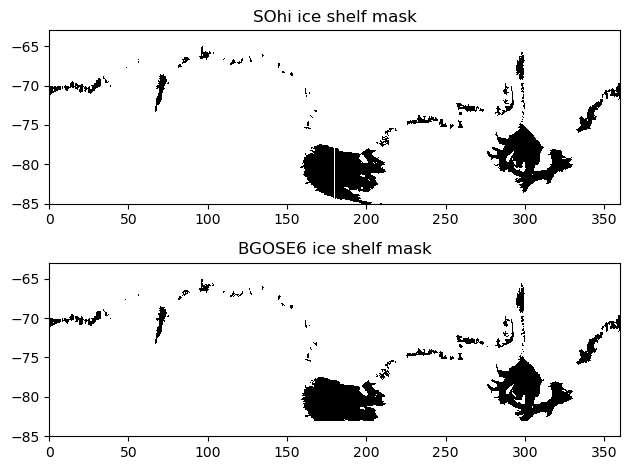

In [9]:
fig, axs = plt.subplots(nrows=2, ncols=1)
(ds_SOhi.ID >= 1).plot(ax=axs[0], cmap="binary", add_colorbar=False)
(ds_BGOSE.ID >= 1).plot(ax=axs[1], cmap="binary", add_colorbar=False)

for i in range(2):
    axs[i].set_ylim([-85, -63])
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")

axs[0].set_title("SOhi ice shelf mask")
axs[1].set_title("BGOSE6 ice shelf mask")
plt.tight_layout()
plt.savefig("figures/mask_comparison_named_bgose6.png", format="png", dpi=150)

In [10]:
ds1 = xr.open_dataset("BGOSE6/SHIfwFlx_bgoseI000_SO_monthly.nc")
test = ds1.SHIfwFlx.mean(dim="time").compute()
test = test != 0
idx_mask = ds_BGOSE.ID >= 1
idx_notmasked = ~idx_mask

In [16]:
test.shape

(614, 2160)

In [17]:
c1 = 60**2 * 365 * 24 * 1e-3  # convert kg m-2 s-1 to m yr-1
melt_nonmasked = c1 * test * idx_notmasked * ds1.SHIfwFlx[-36:, :, :].mean(dim="time")
melt_nonmasked = xr.where(melt_nonmasked, melt_nonmasked, np.nan)

melt_mask_2 = np.ones(shape=np.shape(melt_nonmasked)) * np.nan

for i in range(2160):
    for j in range(614):
        # check that there is both melt and that it is not already included in the first SOhi mask
        if ~np.isnan(ds_BGOSE.ID[j, i]):
            melt_mask_2[j, i] = ds_BGOSE.ID[j, i].data

        elif ~np.isnan(melt_nonmasked[j, i]):
            # create radius that we will check to see how far we are from the any ice shelf
            melt_subgroup = ds_BGOSE.ID[j - 4 : j + 4, i - 4 : i + 4]
            nearby_ids, c = np.unique(melt_subgroup, return_counts=True)

            if len(nearby_ids) == 1:  # this will be just nan
                melt_mask_2[j, i] = 0  # generic flag
            elif (
                len(nearby_ids) == 2
            ):  # there is only 1 ice shelf in the area, name is same as ice shelf
                melt_mask_2[j, i] = nearby_ids[~np.isnan(nearby_ids)]
            elif (
                len(nearby_ids) > 2
            ):  # more than 1 ice shelf nearby -- add to that which has more?
                max_c = np.max(c[~np.isnan(nearby_ids)])
                melt_mask_2[j, i] = -0  # just a stopgap measure
                # if len(c==max_c) == 1:
                #    melt_mask_2[j,i] = nearby_ids[c==max_c]
                # else:
                #    melt_subgroup = ds_BGOSE.ID[j-2:j+2, i-2:i+2]
                #    nearby_ids, c = np.unique(melt_subgroup, return_counts=True)
                #    melt_mask_2[j,i] = nearby_ids[c==max_c]

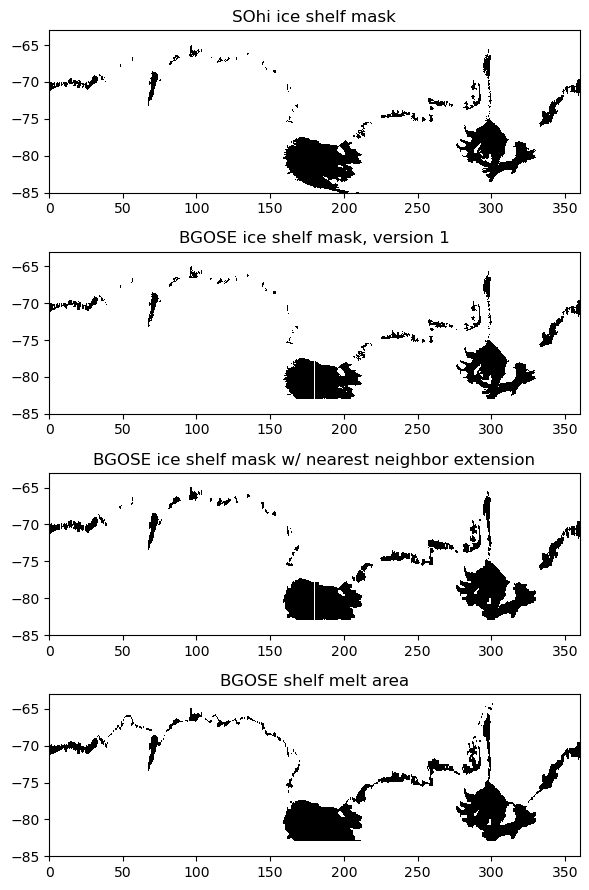

In [18]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6, 9))

(ds_SOhi.ID >= 1).plot(ax=axs[0], cmap="binary", add_colorbar=False)
(ds_BGOSE.ID >= 1).plot(ax=axs[1], cmap="binary", add_colorbar=False)
axs[2].pcolormesh(ds_BGOSE.XC.data, ds_BGOSE.YC.data, melt_mask_2 > 0, cmap="binary")
test.plot(ax=axs[3], cmap="binary", add_colorbar=False)

for i in range(4):
    axs[i].set_ylim([-85, -63])
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")

axs[0].set_title("SOhi ice shelf mask")
axs[1].set_title("BGOSE ice shelf mask, version 1")
axs[2].set_title("BGOSE ice shelf mask w/ nearest neighbor extension")
axs[3].set_title("BGOSE shelf melt area")

plt.tight_layout()
plt.savefig("figures/mask_comparison_named_bgose6_2.png", format="png", dpi=150)

In [20]:
ds_out_mask = xr.Dataset(
    data_vars=dict(
        shelf_mask=(["YC", "XC"], melt_mask_2),
    ),
    coords=dict(
        XC=("XC", ds_BGOSE.XC.data),
        YC=("YC", ds_BGOSE.YC.data),
    ),
)

ds_out_mask.to_netcdf("BGOSE6/iceshelves_bgose6_extended.nc")

## Meltrates by group and area

In [60]:
Names = [
    "Generic",
    "Larsen G",
    "Larsen F",
    "Larsen E",
    "Larsen D",
    "Larsen C",
    "Larsen B",
    "Wordie",
    "Wilkins",
    "Bach",
    "George VI",
    "Stange",
    "Ronne",
    "Ferrigno",
    "Venable",
    "Abbot",
    "Cosgrove",
    "Pine Island",
    "Thwaites",
    "Crosson",
    "Dotson",
    "Getz",
    "Land",
    "Nickerson",
    "Sulzberger",
    "Swinburne",
    "Withrow",
    "Ross West",
    "Ross East",
    "Drygalski",
    "Nansen",
    "Aviator",
    "Mariner",
    "Lillie",
    "Rennick",
    "Cook",
    "Ninnis",
    "Mertz",
    "Dibble",
    "Holmes",
    "Moscow University",
    "Totten",
    "Vincennes",
    "Conger_Glenzer",
    "Tracy_Tremenchus",
    "Shackleton",
    "West",
    "Publications",
    "Amery",
    "Wilma_Robert_Downer",
    "Edward VIII",
    "Rayner_Thyer",
    "Shirase",
    "Prince Harald",
    "Baudouin",
    "Borchgrevink",
    "Lazarev",
    "Nivl",
    "Vigrid",
    "Fimbul",
    "Jelbart",
    "Atka",
    "Ekstrom",
    "Quar",
    "Riiser-Larsen",
    "Brunt_Stancomb",
    "Filchner",
]

In [ ]:
name_width = max(len(n) for n in Names) + 2  # auto width

with open("BGOSE_areas.txt", "w") as f:  # open file for writing
    # header
    print(
        f"{'Region':<{name_width}}{'SOhi (km2)':>15}{'BGOSEv1 (km2)':>15}{'BGOSEv2 (km2)':>15}",
        file=f,
    )

    # rows
    for i in range(1, 67):
        A = ((ds_SOhi.ID == i) * ds_SOhi.area).sum() * 1e-6
        B = ds1.rA.where(ds_BGOSE.ID == i).sum() * 1e-6
        C = ds1.rA.where(ds_out_mask.shelf_mask == i).sum() * 1e-6
        print(
            f"{Names[i]:<{name_width}}{A.data:>15.2f}{B.data:>15.2f}{C.data:>15.2f}",
            file=f,
        )

In [24]:
ds1 = xr.open_dataset("BGOSE6/SHIfwFlx_bgoseI000_SO_monthly.nc")
ds_BGOSE = xr.open_dataset("BGOSE6/iceshelves_bgose6_extended.nc")

In [22]:
c_Gt = -1 * 60**2 * 24 * 365 * 1e-12

In [9]:
Names[1:12]  # Antarctic Peninsula
Names[13:27]  # W Antarctica (no Ronne or Ross)
Names[27:29]  # Ross Sea
Names[29:-1]  # E Antarctica (no Filchner or Ross)
Names[12], Names[-1]  # Ronne-Filchner

type: name 'Names' is not defined

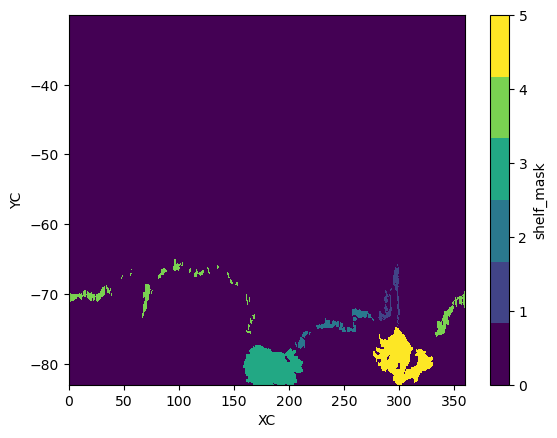

In [25]:
idx_AP = ds_BGOSE.shelf_mask.isin(np.arange(1, 12))
idx_WA = ds_BGOSE.shelf_mask.isin(np.arange(13, 27))
idx_RS = ds_BGOSE.shelf_mask.isin(np.arange(27, 29))
idx_EA = ds_BGOSE.shelf_mask.isin(np.arange(29, 66))
idx_RF = ds_BGOSE.shelf_mask.isin([12, 66])
idx_other = ds_BGOSE.shelf_mask == 0

(idx_AP + 2 * idx_WA + 3 * idx_RS + 4 * idx_EA + 5 * idx_RF).plot(
    cmap=plt.get_cmap("viridis", 6)
)

In [26]:
# for generic ice shelves to be attributed into different regions - ignore RS and RF for now

region_AP = (ds1.YC > -75) & (ds1.YC < -63) & (ds1.XC < 360 - 55) & (ds1.XC > 360 - 80)
region_WA = (ds1.YC > -78) & (ds1.YC < -70) & (ds1.XC < 360 - 80) & (ds1.XC > 360 - 160)
region_EA = (ds1.YC > -78) & (ds1.YC < -64) & ((ds1.XC < 178) | (ds1.XC > 360 - 50))

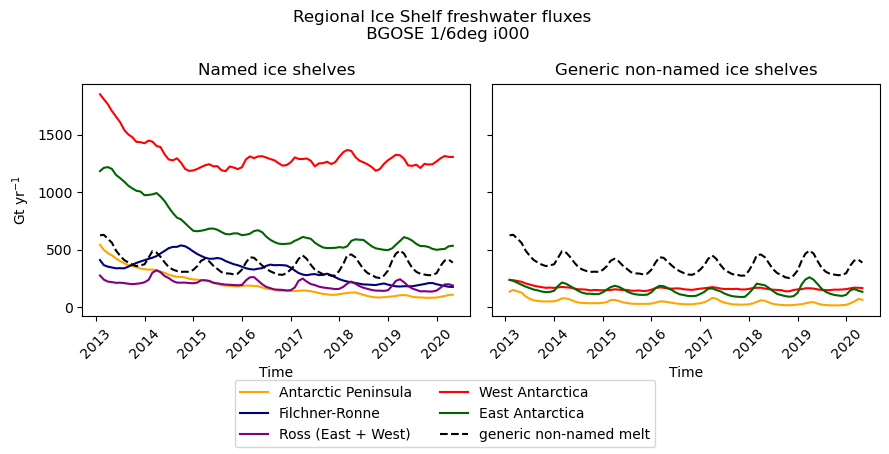

In [29]:
fig, axs = plt.subplots(ncols=2, nrows=1, sharey=True, figsize=(9, 4.5))

(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_AP).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="orange", label="Antarctic Peninsula"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_RF).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="navy", label="Filchner-Ronne"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_RS).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="purple", label="Ross (East + West)"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_WA).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="red", label="West Antarctica"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_EA).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="darkgreen", label="East Antarctica"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other).sum(dim=["XC", "YC"]).plot(
    ax=axs[0], color="black", linestyle="dashed", label="generic non-named melt"
)

(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="black", linestyle="dashed", label="generic non-named melt"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other * region_AP).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="orange", label="Antarctic Peninsula"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other * region_WA).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="red", label="West Antarctica"
)
(c_Gt * ds1.rA * ds1.SHIfwFlx * idx_other * region_EA).sum(dim=["XC", "YC"]).plot(
    ax=axs[1], color="darkgreen", label="East Antarctica"
)

#axs[0].legend()
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2)
axs[0].set_ylabel("Gt yr$^{-1}$")

plt.suptitle("Regional Ice Shelf freshwater fluxes \n BGOSE 1/6deg i000")
axs[0].set_title("Named ice shelves")
axs[1].set_title("Generic non-named ice shelves")

for i in range(2):
    axs[i].tick_params(axis="x", labelrotation=45)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
#plt.show()

plt.savefig("figures/BGOSE6i000_regional_flux_incl_generic.png", format="png", dpi=150)

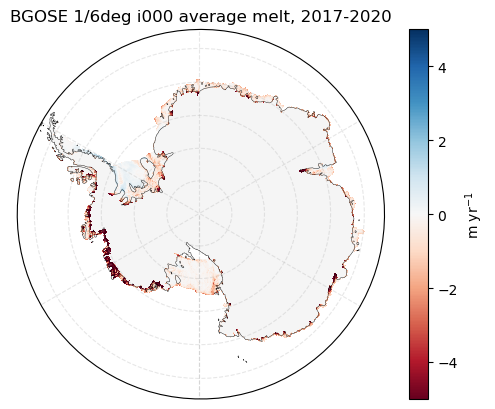

2026-04-20 00:01:27,697 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 0 memory: 55 MB fds: 275>>
Traceback (most recent call last):
  File "/Users/keturner/opt/anaconda3/envs/SO_storms/lib/python3.11/site-packages/tornado/ioloop.py", line 921, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/Users/keturner/opt/anaconda3/envs/SO_storms/lib/python3.11/site-packages/distributed/system_monitor.py", line 160, in update
    net_ioc = psutil.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/keturner/opt/anaconda3/envs/SO_storms/lib/python3.11/site-packages/psutil/__init__.py", line 2114, in net_io_counters
    rawdict = _psplatform.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 12] Cannot allocate memory


In [30]:
c1 = 60**2 * 365 * 24 * 1e-3  # convert kg m-2 s-1 to m yr-1

# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

avg_melt = c1 * ds1.SHIfwFlx[-36:, :, :].mean(dim="time")
avg_melt = xr.where(avg_melt, avg_melt, np.nan)

ax = plt.axes(projection=ccrs.SouthPolarStereo())

avg_melt.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-5,
    vmax=5,
    extend="neither",
    cmap="RdBu",
    cbar_kwargs={"label": "m yr$^{-1}$"},
)
ax.set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
ax.gridlines(alpha=0.3, linestyle="dashed")
ax.set_boundary(circle, transform=ax.transAxes)
ax.coastlines(linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")

plt.title("BGOSE 1/6deg i000 average melt, 2017-2020")
plt.savefig("figures/BGOSE6i000_avg_flux.png", format="png", dpi=150)

In [ ]:
avg_melt = c1 * ds1.SHIfwFlx[24 + 6 :: 12, :, :].mean(dim="time")
avg_melt = xr.where(avg_melt, avg_melt, np.nan)

In [ ]:
ax = plt.axes(projection=ccrs.SouthPolarStereo())

avg_melt.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-5,
    vmax=5,
    extend="neither",
    cmap="RdBu",
    cbar_kwargs={"label": "m yr$^{-1}$"},
)
ax.set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
ax.gridlines(alpha=0.3, linestyle="dashed")
ax.set_boundary(circle, transform=ax.transAxes)
ax.coastlines(linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")

plt.title("BGOSE i012 August average melt, 2015-2023")
plt.savefig("figures/BGOSE_aug_flux.png", format="png", dpi=150)

In [ ]:
year_offset = 4

melt_mar = xr.where(
    -1 * c1 * ds1.SHIfwFlx[year_offset * 12 + 1, :, :],
    -1 * c1 * ds1.SHIfwFlx[year_offset * 12 + 1, :, :],
    np.nan,
)
melt_aug = xr.where(
    -1 * c1 * ds1.SHIfwFlx[year_offset * 12 + 6, :, :],
    -1 * c1 * ds1.SHIfwFlx[year_offset * 12 + 6, :, :],
    np.nan,
)

fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(8, 11))

axs = axs.flatten()

for i in np.arange(0, 15, 3):
    ds1.Depth.plot.contourf(
        ax=axs[i], cmap="binary", vmin=0, vmax=1000, levels=10, add_colorbar=False
    )
    if i == 9:
        melt_mar.plot(ax=axs[i], vmin=-25, vmax=25, cmap="RdBu_r", cbar_kwargs={"label": ""})
    else:
        melt_mar.plot(ax=axs[i], vmin=-5, vmax=5, cmap="RdBu_r", cbar_kwargs={"label": ""})
    axs[i].set_title("")
    axs[i].set_ylabel("")
    axs[i].set_xlabel("")
    axs[i].set_box_aspect(1)

for i in np.arange(1, 15, 3):
    ds1.Depth.plot.contourf(
        ax=axs[i], cmap="binary", vmin=0, vmax=1000, levels=10, add_colorbar=False
    )
    if i == 10:
            melt_aug.plot(ax=axs[i], vmin=-25, vmax=25, cmap="RdBu_r", cbar_kwargs={"label": ""})
    else:
        melt_aug.plot(ax=axs[i], vmin=-5, vmax=5, cmap="RdBu_r", cbar_kwargs={"label": ""})
    axs[i].set_title("")
    axs[i].set_ylabel("")
    axs[i].set_xlabel("")
    axs[i].set_box_aspect(1)
    
for i in np.arange(2, 15, 3):
    ds1.Depth.plot.contourf(
        ax=axs[i], cmap="binary", vmin=0, vmax=1000, levels=10, add_colorbar=False
    )
    (melt_aug - melt_mar).plot(ax=axs[i], vmin=-3, vmax=3, cmap="RdBu_r", cbar_kwargs={"label": ""})
    axs[i].set_title("")
    axs[i].set_ylabel("")
    axs[i].set_xlabel("")
    axs[i].set_box_aspect(1)

for i in range(3):
    axs[i].set_ylim([-85, -74])
    axs[i].set_xlim([270, 331])

for i in range(3, 6):
    axs[i].set_ylim([-86, -76])
    axs[i].set_xlim([155, 214])

for i in range(6, 9):
    axs[i].set_ylim([-74, -67])
    axs[i].set_xlim([66, 75])

for i in range(9, 12):
    axs[i].set_ylim([-75.7, -74.1])
    axs[i].set_xlim([256.5, 261.5])

for i in range(12, 15):
    axs[i].set_ylim([-67.5, -64.5])
    axs[i].set_xlim([93, 103])
    
axs[0].set_title('March 2017 melt')
axs[1].set_title('August 2017 melt')
axs[2].set_title('August-March difference')

plt.tight_layout()
plt.savefig('figures/shelf_melt_maps.png', format='png', dpi=150)

## Seasonality of ice shelf meltwater fluxes

In [3]:
fw_flux_clim = ds1.SHIfwFlx.groupby(ds1.time.dt.month).mean() * -1
mask= xr.where(fw_flux_clim[0,:,:]==0, np.nan, 1)

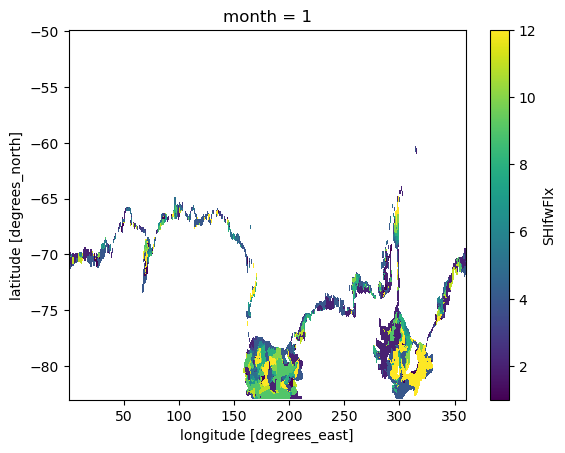

In [19]:
(1 + mask * fw_flux_clim.argmax(dim='month', skipna=True)).plot()#cmap=cmo.cm.phase)

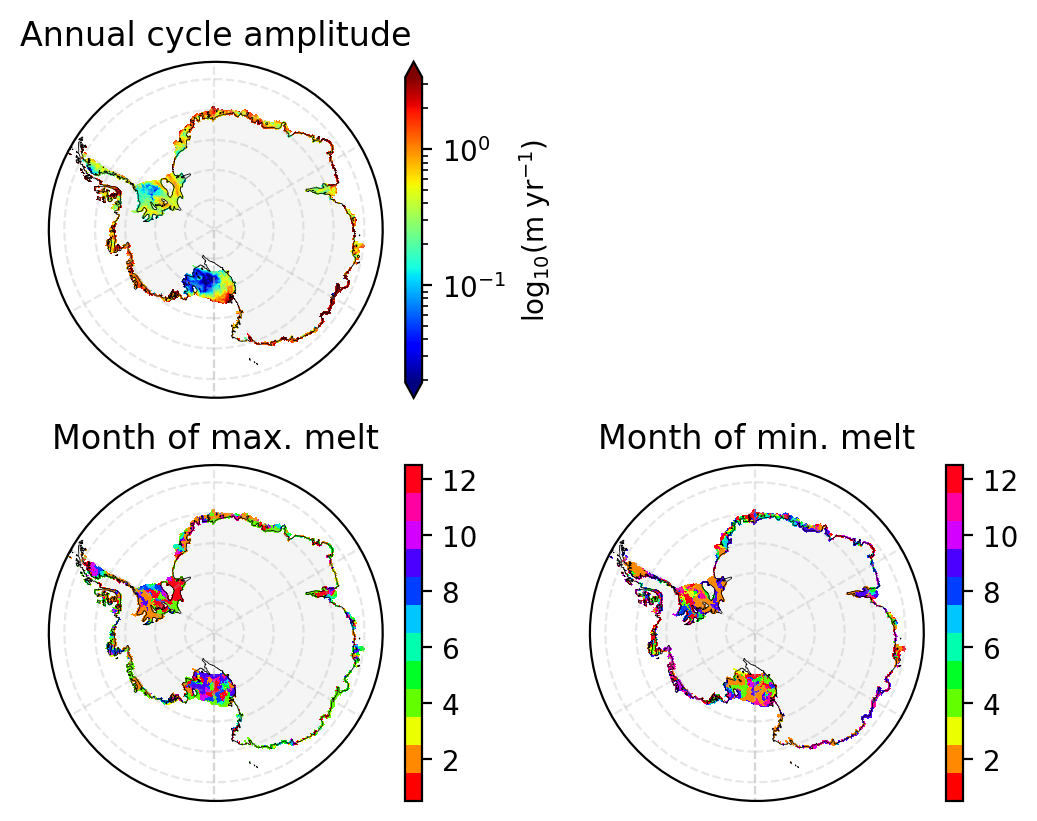

In [119]:
c1 = 60**2 * 365 * 24 * 1e-3  # convert kg m-2 s-1 to m yr-1

# parameters for setting circular cutoff for Southern Ocean plots
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

fig, axs = plt.subplots(ncols=2, nrows=2, 
                        dpi=200,
                        subplot_kw={'projection': ccrs.SouthPolarStereo()})

axs=axs.flatten()

(c1 * mask * (fw_flux_clim.max(dim='month', skipna=True) - fw_flux_clim.min(dim='month', skipna=True))).plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    norm=matplotlib.colors.LogNorm(),
    robust=True,
    cmap='jet',
    #vmin=-4,
    #vmax=2,
    #extend="neither",
    #cmap=cmo.cm.phase,
    cbar_kwargs={"label": "log$_{10}$(m yr$^{-1}$)"},
)
axs[0].set_title('Annual cycle amplitude')

(1 + mask * fw_flux_clim.argmax(dim='month', skipna=True)).plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    vmin=0.5,
    vmax=12.5,
    #extend="neither",
    cmap=plt.get_cmap('hsv', 12),
    cbar_kwargs={"label": ""},
)
axs[2].set_title('Month of max. melt')

(1 + mask * fw_flux_clim.argmin(dim='month', skipna=True)).plot(
    ax=axs[3],
    transform=ccrs.PlateCarree(),
    vmin=0.5,
    vmax=12.5,
    #extend="neither",
    cmap=plt.get_cmap('hsv', 12),
    cbar_kwargs={"label": ""},
)
axs[3].set_title('Month of min. melt')

for i in range(4):
    axs[i].set_extent([-180, 180, -90, -62], ccrs.PlateCarree())
    axs[i].gridlines(alpha=0.3, linestyle="dashed")
    axs[i].set_boundary(circle, transform=axs[i].transAxes)
    axs[i].coastlines(linewidth=0.3)
    axs[i].add_feature(cfeature.LAND, facecolor="whitesmoke")
    
axs[1].remove()

plt.savefig('figures/annual_cycle.png', format='png', dpi=200)

In [70]:
Names[17:19]

['Pine Island', 'Thwaites']

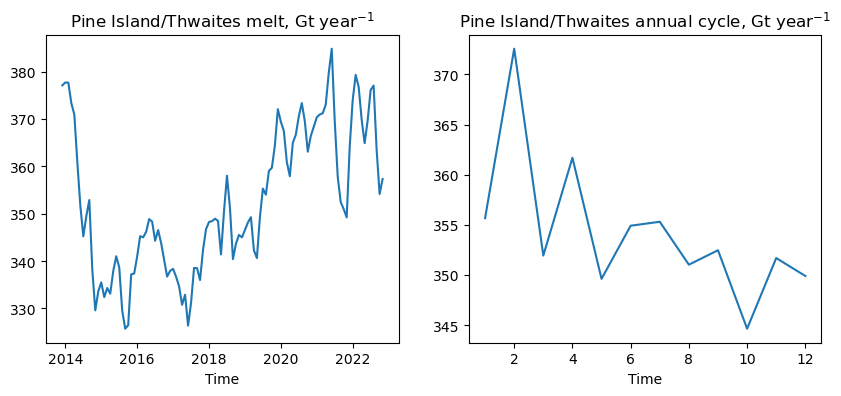

In [148]:
PI_T_melt = (c_Gt * ds1.rA * ds1.SHIfwFlx[12:,:,:]).sel(YC=slice(-75.7,-73.95)).sel(XC=slice(251,261)).sum(dim=['YC', 'XC'])

fig, axs = plt.subplots(figsize = (10,4), nrows=1, ncols=2)
PI_T_melt.plot(ax=axs[0])
axs[0].set_xticks(PI_T_melt.time[1::24])
axs[0].set_xticklabels(PI_T_melt.time[1::24].dt.year.data)
axs[0].set_title('Pine Island/Thwaites melt, Gt year$^{-1}$')

PI_T_melt.groupby(PI_T_melt.time.dt.month).mean().plot()
axs[1].set_title('Pine Island/Thwaites annual cycle, Gt year$^{-1}$')

plt.savefig('figures/BGOSEi013_PI_T_ts.png', format='png', dpi=100)

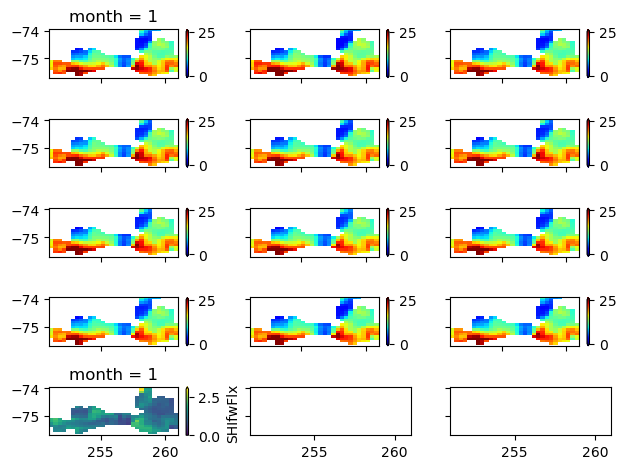

In [117]:
fig, axs = plt.subplots(nrows=5, ncols=3, sharex=True, sharey=True)

axs = axs.flatten()

for i in range(12):

    (c1 * mask * fw_flux_clim[i,:,:]).plot(ax=axs[i], vmin=0, vmax=25, cmap='jet',
                                          cbar_kwargs={"label": ""},
                                          )
    
(c1 * mask * (fw_flux_clim.max(dim='month', skipna=True) - fw_flux_clim.min(dim='month', skipna=True))).plot(
    ax=axs[12],
    vmin=0, vmax=3)
    
for i in range(15):
    axs[i].set_ylim([-75.7, -73.95])
    axs[i].set_ylabel('')
    axs[i].set_xlim([251,261])
    axs[i].set_xlabel('')
    
plt.tight_layout()

In [72]:
ds1

<xarray.Dataset> Size: 164MB
Dimensions:   (time: 120, XC: 1080, YC: 307)
Coordinates:
    iter      (time) int64 960B ...
  * time      (time) datetime64[ns] 960B 2012-12-31T10:00:00 ... 2022-11-29
  * XC        (XC) float32 4kB 0.1667 0.5 0.8333 1.167 ... 359.2 359.5 359.8
  * YC        (YC) float32 1kB -82.98 -82.94 -82.9 ... -50.43 -50.22 -50.0
    rA        (YC, XC) float32 1MB ...
    Depth     (YC, XC) float32 1MB ...
    rLowC     (YC, XC) float32 1MB ...
    rSurfC    (YC, XC) float32 1MB ...
Data variables:
    SHIfwFlx  (time, YC, XC) float32 159MB ...